## BMEB W4020: Circuits in the Brain 2025 Fall Homework #1

Author: [Shashwat Shukla](shashwat.shukla@columbia.edu), [Bruce Yi Bu](yb2520@columbia.edu)

Based on Previous Work by: Yinghao Li, Tingkai Liu, Mehmet Kerem Turkcan, Chung-Heng Yeh, Konstantinos Psychas

Copyright 2025 Shashwat Shukla, Tingkai Liu, Bruce Yi Bu, and Aurel A. Lazar

### Names and UNIs
Alexander Speer [aes2376]

### Before you start...
#### The code skeleton
* we provide a skeleton of the code for HW1 and all future assignments (excluding the projects)
* you will find helper functions as well as headers of functions that need to be completed (look for "**TO DO**" comments)
* note that you are not strictly required to follow this sequence but it is highly preferred; the skeleton is just provided for convenience but we highly recommend using it, and you are free to modify it or add custom functions to it.

#### Miscellaneous (attention)
* please remember to include your name in the corresponding field at the start of this notebook, otherwize an automatic 0 grade will be received for all team members
* please post your questions on Ed Discussions, and attend the office hours (every Thursday evening)
* please clearly present your solutions and answers with proper use of plots, markdown and comments
* please start the assignment as soon as possible, submission deadlines are strictly followed and late submissions will receive a 10% penalty for each 24 hours post the deadline
* please email the TA/CAs at least 48hrs ahead of the deadline if you cannot submit an assignment on time (due to exam schedules or overwhelming deadlines, etc), we are flexible as long as we are informed.

## PROBLEM: The Morris-Lecar Model
### Part 1: Solving the Reduced Hodgkin-Huxley Model Numerically
In this problem you are asked to implement (solve) a Morris-Lecar mode that is a two-dimentional reduced form of the Hodgkin-Huxley model. It is a further simplification of the Rinzel model.

The Morris\-Lecar model is described by the differential equations:

\begin{equation}
\begin{split}
C\,\frac{dV}{dt} &= I_{\text{ext}}
- g_1\,m_0(V)\,(V - E_1)
- g_2\,w\,(V - E_2)
- g_{\mathrm{L}}\,(V - E_{\mathrm{L}}), \\
\frac{dw}{dt} &= -\frac{1}{\tau(V)} (w - w_0(V)),
\end{split}
\end{equation}

- $V$: membrane potential (mV)  
- $w$: a recovery variable that is dimensionless, 0–1 (analogous to the $n,h$ in HH model)  
- $I_{\text{ext}}$: applied current ($\mu\text{A}/\text{cm}^2$)  
- $C$: membrane capacitance ($(\mu\text{F}/\text{cm}^2$)  
- $g_1, g_2, g_{L}$: maximal conductances (mS/cm²); $g_1$ and $g_2$ are analogous to $g_{Na}$ and $g_K$, $g_L$ remains leaky channel
- $E_1, E_2, E_{L}$:  reverse potentials (mV)  
  

This model uses sigmoidal curves to model a quasi steady state approximate the voltage dependence of the gate activations:


\begin{equation}
\begin{split}m_0(V) &= \tfrac{1}{2}\left[1 + \tanh\!\left(\frac{V - V_1}{V_2}\right)\right], \\
w_0(V) &= \tfrac{1}{2}\left[1 + \tanh\!\left(\frac{V - V_3}{V_4}\right)\right], \\
\tau(V) &= \frac{\tau_w}{\cosh\!\left(\frac{V - V_3}{2V_4}\right)}.
\end{split}
\end{equation}

- $m_0(V)$: quasi steady state of activation  
- $w_0(V)$: quasi steady state of recovery  
- $\tau_w$: time constant of $w$ (ms)
- $V_1, V_2, V_3, V_4$: shape and move the curves

The parameters are given below:
|$g_1$|$E_1$|$g_2$|$E_2$|$g_{L}$|$E_{L}$|
|:----|:-----|:---|:---|:---|:---|
|<img style="width:100px">1.1 $mS/cm^2$|<img style="width:100px">100 $mV$|<img style="width:100px">2.0 $mS/cm^2$|<img style="width:100px">-70 $mV$|<img style="width:100px">0.5 $mS/cm^2$|<img style="width:100px">-50 $mV$|

|$C$|$V_1$|$V_2$|$V_3$|$V_4$|$\tau_w$|
|:---|:---|:---|:---|:---|:---|
|<img style="width:100px">1 $\mu F/cm^2$|<img style="width:100px">-1.2 $mV$|<img style="width:100px">18 $mV$|<img style="width:100px">2 $mV$|<img style="width:100px">30 $mV$|<img style="width:100px">15|



    
Create an input current of the form
$$I(t)= \sum^{10}_{k=0}a_k \frac{\sin \Omega (t-kT)}{\Omega (t-kT)}$$
where $a_k = constant (\mu A/cm^2), 0 \leq k \leq 10$, $\Omega = 2 \pi \cdot 15$ Hz, $T = \pi/\Omega$,
$t \in [0, 800]$ ms.

1. Implement the Morris-Lecar neuron model defined by the equations above. You are asked to implement [Euler's method](https://en.wikipedia.org/wiki/Euler_method) for solving differential equations numerically. Essentially, for the differential equation $\frac{dx}{dt} = f(x) + I(t)$, we iteratively evaluate the value of $x(t+\Delta t)$ given the previous value $x(t)$ and the gradient of $f(x(t)) + I(t)$ as $\frac{x(t+\Delta t) - x(t)}{\Delta t} = f(x(t)) + I(t)$.

2. Assuming that $a_k=constant, -M \le m \le M$, with initial conditions $V(0)=-60mV, w(0)=0.01 (unitless)$, plot the input and the output of the Morris-Lecar neuron on the time interval [0, 800] ms, using an $a_k$ such that the neuron robustly spikes.
    * Make sure to show one plot featuring both input current and membrane voltage. You can use the `.twinx()` function in `matplotlib` (google documentation if you wish) to create two y-axes in one plot.
    * We recommend experimenting with a wide range of $a_k$ values to see its effect on the voltage spikes.  
3. Empirically determine a range of values for the $a_k$'s that makes the neuron fire. Plot the total number of spikes fired in the interval [0, 800] ms for a broad range of $a_k = constant$ values. For the same range of input current values, show the following
    1. spike count
    2. spike rate (spikes per second)
    3. spike amplitude (Voltage value at spike time)
4. Assume the input current is $I(t) = c\cdot u(t)$, where $u(t)$ is a [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function), and $c$ is amplitude of the injected current in $\mu A/cm^2$. Find a range of values for $c$ such that the Moris_Lecar neuron exhibits periodic spiking (limit cycle). Draw the limit cycle in the $V$ vs. $w$ plane for at least 3 different values of $c$, comment on the effect of the amplitude $c$ on the limit cycle and the membrane voltage based on your results.

# **Cell 1**

In [1]:
# Import libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # fix random seed

# **Cell 2**

In [2]:
# Define spike detection function
def spike_detect(v, thresh):
    x = (v[2:-1] > v[1:-2]) * (v[2:-1] > v[3:]) * (v[2:-1] > thresh)
    x = np.append(False, x)
    x = np.append(x, False)
    return x

# **Cell 3**

In [3]:
# TODO - define a function to generate the input current
# the function should take the following form:
#
# I_in(t, a, K, omega)
#   input: (t, a, K, omega),
#          t = basically just a time vector (ms)
#          a = should just be a scalar  --> with the shared a_k value
#          K = an integr upper limit
#          omega = the angular freq.
#   output: I(t) is just a numpy array.

def I_in(t, a, K, omega):
    T = np.pi / omega   # this just gives us the time shit in ms between successful pulses
    I = np.zeros_like(t, dtype=float)

    for k in range(K+1): #term x term sum
        denom = omega * (t - k*T)
        term = np.divide(np.sin(denom), denom, out=np.ones_like(denom), where=denom!=0)
        #just safely computes the comp making sure that x = 0 is handled properly. (sub 1 in since limit sinx/x = 1)
        term[np.isnan(term)] = 1.0
        I += a * term

    return I


# **Cell 4**

In [4]:
# Morris Lecar model morris-lecar
# Create a function to define the wilson model
# that takes in injection current and time vector as inpuit
# and return V and w as vectors
# Pay attention to time scale (ms vs s)!

# the fabulous Morris-Lecar model
def morris_lecar(t, I_ext):

    C = 1.0
    g1, E1 = 1.2, 100.0
    g2, E2 = 2.0, -70.0
    gL, EL = 0.5, -50.0
    V1, V2, V3, V4 = -1.2, 18.0, 2.0, 30.0
    tau_w_const = 15.0

    dt = t[1] - t[0]  # in ms
    V = np.zeros_like(t)
    w = np.zeros_like(t)

    # Initial conditions that we set for us
    V[0] = -60.0   #mV
    w[0] = 0.01   #all channels basically being close to closed

    # Helper functions
    m_inf = lambda V: 0.5 * (1 + np.tanh((V - V1) / V2)) #steady state calcium
    w_inf = lambda V: 0.5 * (1 + np.tanh((V - V3) / V4)) # steady state potassium
    tau_w = lambda V: 1.0 / np.cosh((V - V3) / (2 * V4)) #v gate time constant for w

    # Euler
    for i in range(len(t)-1):
        dVdt = (-g1 * m_inf(V[i]) * (V[i] - E1)
                - g2 * w[i] * (V[i] - E2) #
                - gL * (V[i] - EL)
                + I_ext[i]) / C
        dwdt = (w_inf(V[i]) - w[i]) / (tau_w_const * tau_w(V[i])) #recovery eqn

        V[i+1] = V[i] + dt * dVdt
        w[i+1] = w[i] + dt * dwdt

    return V, w


# **Cell 5**

In [5]:
# TO DO: simulate the model and detect the spikes

# parameters for simulation
dt = 0.01  #ms
t = np.arange(dt, 800+dt, dt)

# the base input current (really low, no APs)
a = 0.5 #0.5 <-- adjust higher for spikes.
K = 10
omega = 2 * np.pi * 15 / 1000  # angular freq 15 Hz????
I_ext = I_in(t, a, K, omega) #from Cell3

# after computing I_ext
assert not np.isnan(I_ext).any(), "I_in produced NaNs --> you have to fix the divide-by-zero problem)."

#runtime
V, w = morris_lecar(t, I_ext)

# more permissive spike threshold, wasn't seeing a lot at action at 0
spikes = spike_detect(V, -20)
if len(spikes) < len(V):
    spikes = np.append(spikes, False)  # pad to match length of prev vector
spike_times = t[spikes]

print(f"total spikes detected: {spikes.sum()}")
print(f"V range: min={V.min():.1f} mV, max={V.max():.1f} mV")


total spikes detected: 0
V range: min=-60.0 mV, max=-48.9 mV


# **Cell 6**

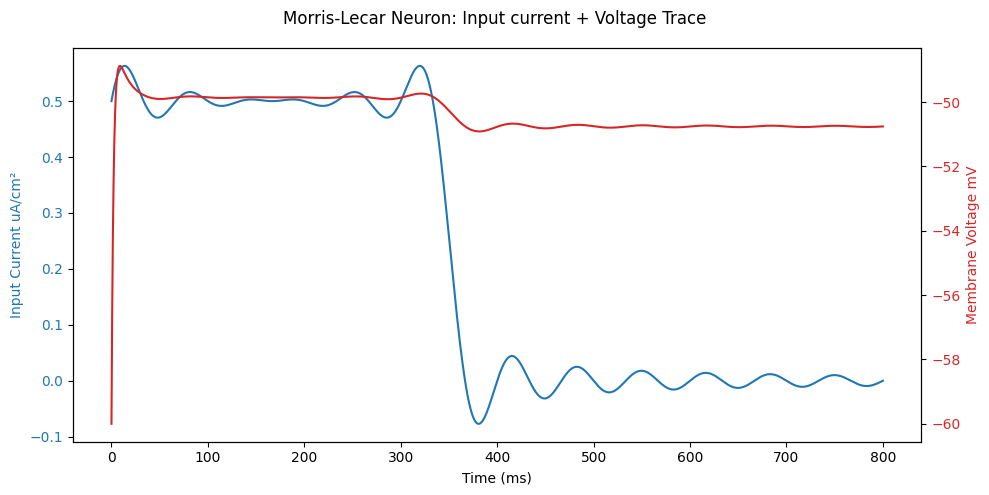

In [6]:
# TO DO: plot the results

fig, ax1 = plt.subplots(figsize=(10, 5))

#input current on the left y-axis
ax1.plot(t, I_ext, color='tab:blue', label='Input Current I(t)')
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Input Current uA/cm²", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

#the we do voltage on right y-axis
ax2 = ax1.twinx()
ax2.plot(t, V, color='tab:red', label='Membrane Voltage V(t)')
ax2.set_ylabel("Membrane Voltage mV", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

#mark any of the detected spikes we see (none really at 0.5 a)
if np.any(spikes):
    ax2.scatter(t[spikes], V[spikes], color='black', marker='o', s=20, label='Spikes')


fig.suptitle("Morris-Lecar Neuron: Input current + Voltage Trace")
fig.tight_layout()
plt.show()


# **Cell 7**

In [7]:
# Determine the range where the neuron robustly fires
# TO DO: perform the experiment by first defining the range of amplitudes

dt = 0.01
t = np.arange(dt, 800+dt, dt)
K = 10
omega = 2 * np.pi * 15 / 1000 #same pulsing I

amplitudes = np.linspace(0, 50, 20)  # inistlaly swept from 0-20, but tried 50, helps determine ~30 is best
spike_counts = []  #also makes suer that they are all evenly spaced out as well.

for a in amplitudes:
    I_ext = I_in(t, a, K, omega)
    V, w = morris_lecar(t, I_ext)
    spikes = spike_detect(V, -20) #somewhat lower than I would have liked.
    if len(spikes) < len(V):   # just in case!!!!
        spikes = np.append(spikes, False)
    spike_counts.append(spikes.sum()) #

for a, count in zip(amplitudes, spike_counts):
    print(f"a = {a:.2f} uA/cm² → spikes: {count}")


a = 0.00 uA/cm² → spikes: 0
a = 2.63 uA/cm² → spikes: 0
a = 5.26 uA/cm² → spikes: 0
a = 7.89 uA/cm² → spikes: 1
a = 10.53 uA/cm² → spikes: 1
a = 13.16 uA/cm² → spikes: 2
a = 15.79 uA/cm² → spikes: 8
a = 18.42 uA/cm² → spikes: 9
a = 21.05 uA/cm² → spikes: 10
a = 23.68 uA/cm² → spikes: 11
a = 26.32 uA/cm² → spikes: 11
a = 28.95 uA/cm² → spikes: 11
a = 31.58 uA/cm² → spikes: 12
a = 34.21 uA/cm² → spikes: 11
a = 36.84 uA/cm² → spikes: 11
a = 39.47 uA/cm² → spikes: 8
a = 42.11 uA/cm² → spikes: 8
a = 44.74 uA/cm² → spikes: 6
a = 47.37 uA/cm² → spikes: 6
a = 50.00 uA/cm² → spikes: 6


# **Cell 8**

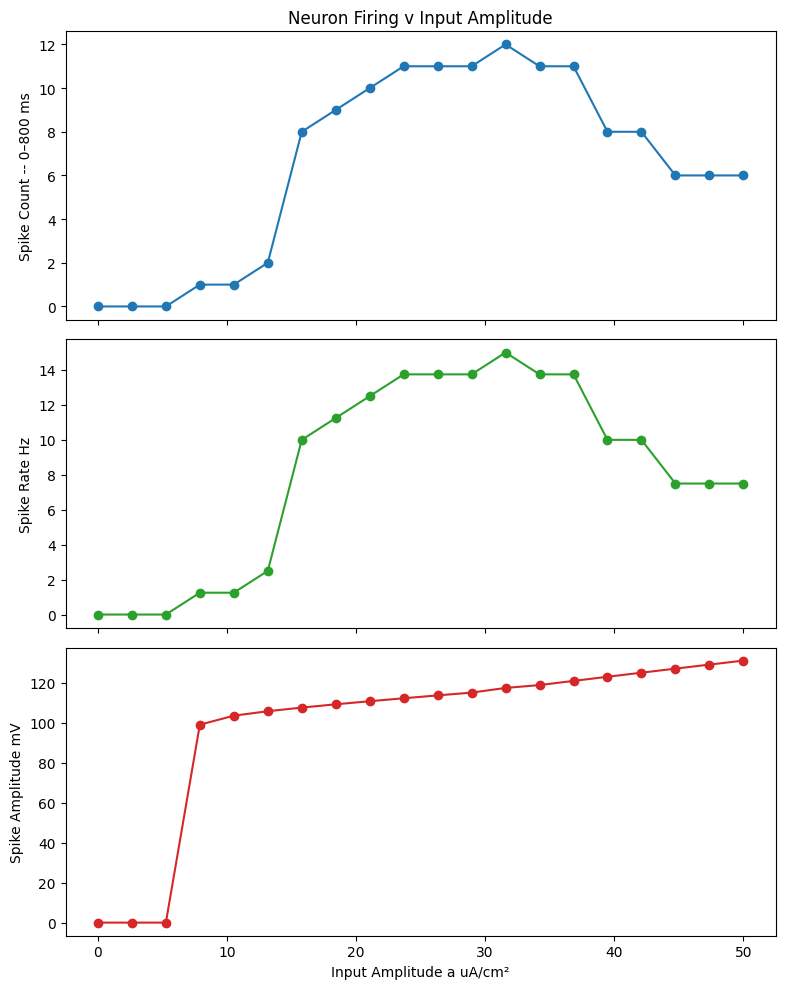

In [8]:
# plotting all of the metrics across the different amplitudes.
spike_counts = []
spike_rates = []
spike_amplitudes = []

duration_ms = 800 #per questoin
duration_s = duration_ms / 1000

for a in amplitudes:
    I_ext = I_in(t, a, K, omega)
    V, w = morris_lecar(t, I_ext)
    spikes = spike_detect(V, -20)
    if len(spikes) < len(V):
        spikes = np.append(spikes, False)
    spike_times = t[spikes]

    # just making extra sure that code restricts to 800ms
    valid = (spike_times >= 0) & (spike_times <= duration_ms)
    count = np.sum(valid)

    #spike rate
    rate = count / duration_s

    # spike amplitude
    if count > 0:
        amp = np.max(V[spikes]) - np.min(V)
    else:
        amp = 0

    spike_counts.append(count)
    spike_rates.append(rate)
    spike_amplitudes.append(amp)

# --> arrays
spike_counts = np.array(spike_counts)
spike_rates = np.array(spike_rates)
spike_amplitudes = np.array(spike_amplitudes)

#then plotted.
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axs[0].plot(amplitudes, spike_counts, 'o-', color='tab:blue')
axs[0].set_ylabel("Spike Count -- 0–800 ms")
axs[0].set_title("Neuron Firing v Input Amplitude")

axs[1].plot(amplitudes, spike_rates, 'o-', color='tab:green')
axs[1].set_ylabel("Spike Rate Hz")

axs[2].plot(amplitudes, spike_amplitudes, 'o-', color='tab:red')
axs[2].set_xlabel("Input Amplitude a uA/cm²")
axs[2].set_ylabel("Spike Amplitude mV")

plt.tight_layout()
plt.show()



# **Cell 9**

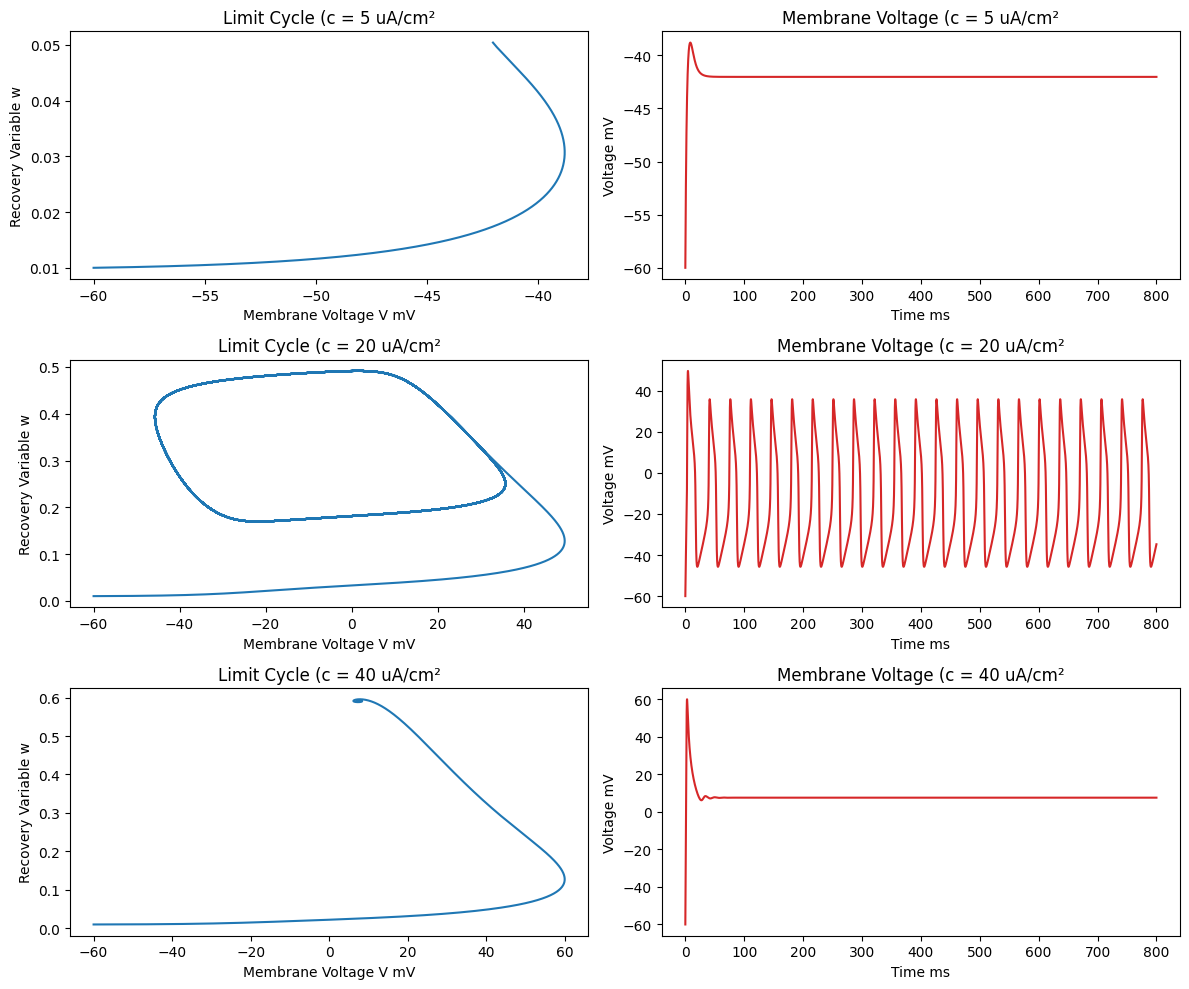

In [9]:
# For Heaviside step function current input, determine range of c to make the model periodically spike
# We recomment picking three values to show where the neuron
# 1. c smaller than the range
# 2. c within the range
# 3. c over the range
# TO DO: for each case above, plot limit cycle (V vs w) and the membrane voltage vs time


dt = 0.01
t = np.arange(dt, 800+dt, dt)

# Define Heaviside input
def heaviside_current(t, c):
    return c * np.ones_like(t)

# Choose three c values based on the outputs from the prev. question
c_values = [5, 20, 40]  # adjust if needed after testing done in Cell 7. G0 back and change if you change anything in notebook.

fig, axes = plt.subplots(len(c_values), 2, figsize=(12, 10))

for idx, c in enumerate(c_values):
    I_ext = heaviside_current(t, c)
    V, w = morris_lecar(t, I_ext)

    # Plot V vs w
    axes[idx, 0].plot(V, w, color='tab:blue')
    axes[idx, 0].set_xlabel("Membrane Voltage V mV")
    axes[idx, 0].set_ylabel("Recovery Variable w")
    axes[idx, 0].set_title(f"Limit Cycle (c = {c} uA/cm²")

    #plot V vs time
    axes[idx, 1].plot(t, V, color='tab:red')
    axes[idx, 1].set_xlabel("Time ms")
    axes[idx, 1].set_ylabel("Voltage mV")
    axes[idx, 1].set_title(f"Membrane Voltage (c = {c} uA/cm²")

plt.tight_layout()
plt.show()


#### TO DO: (double click to edit)
### Comment on the effect of c on the limit cycle and membrane voltage


I think from the simulations that were just run, the behavior of the Morris–Lecar neuron essentially strongly depends on the amplitude c found in the constant Heaviside step input:


- **c below threshold:**
  For this below threshold value I just 5 uA. When using this value, we find that the neuron does not actually fire action potentials. Instead, the membrane voltage settles to a stable fixed point, and in the phase plane that we made, the trajectory just collapses to a single point rather than forming a loop like we see in other examples.


- **c within the spiking range:**  
  In Cell 7 we ran some tests and I decided to just go with 20 uA. During this condition, the neuron exhibits sustained and periodic spiking. The voltage trace generated shows regular action potentials, and in the phase plane the trajectory forms we see a closed limit cycle, which would represent the stable oscillatory state of the neuron


- **c above the range (e.g., c = 40 μA/cm²):**  
  I chose 40 uA since the Action Potentials were on the decline by this point in the previous simulation. We find that the neuron initially depolarizes but then enters a sort of depolarization block, where it then stays near 0 mV without any further spiking. We also see that once again, the phase plane trajectory collapses to a fixed point.


**Summary**
At a low c value, the neuron is silent; at an intermediate c, it starts to spike periodically (limit cycle); at a high c value, the neuron is driven into a depolarization block. I would say this is demonstrative of how the input current amplitude controls whether the system’s stable state is going to be a rest point, a limit cycle, or a just depolarized fixed point.



# **Part 2: Analyzing the Internal State of the Morris-Lecar Model**

As done in Chapter 3 for the Na and K channels of a Hodgkin-Huxley neuron, in this part, we model the variable $w$ of the Morris-Lecar neuron as a memconductance.
1. Write down Ohm's law for $I_{w}$ and the differential equation for $I_w$, treating the current $I_w$ as input.
2. Assuming (a) ramp and (b) spike train input currents, plot the voltage $V_w=V-E_2$ versus current $I_w$. Is $V_w$ a function of the current $I_w$?
3. Is the flux $\phi_w (t) = \int_0^t V_w(s) ds$ a function of the charge $q_w (t) = \int_0^t I_w (s) ds$?

### Ohm’s law for the \(w\)-branch (K-like channel)

$$
V_w \equiv V - E_2, \qquad I_w = g_2\,w\,(V - E_2) = g_2\,w\,V_w
$$

### Differential equation for \(I_w\)

Differentiate \(I_w = g_2 w (V - E_2)\):

$$
\frac{d I_w}{dt}
= g_2\!\left(\frac{dw}{dt}\,(V - E_2) \;+\; w\,\frac{dV}{dt}\right)
$$

Here, \(V\) is going to be the membrane potential, where \(w\) is the recovery variable,  then we find
\(E_2\) as the reversal potential, and \(g_2\) as the maximal conductance.


# **Cell 10**

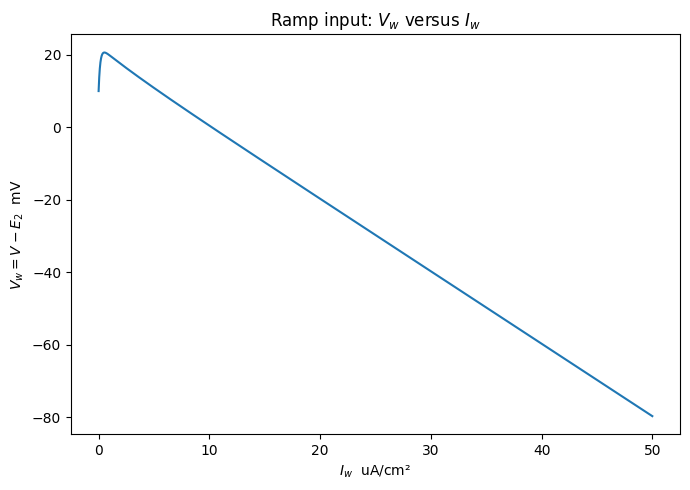

In [10]:
# Q2: Ramp current input
# Treat I_w as the input to the w-branch: replace -g2*w*(V-E2) with -I_w(t)

def morris_lecar_with_Iw(t, Iw_t, I_ext=None):
    C = 1.0
    g1, E1 = 1.2, 100.0
    gL, EL = 0.5, -50.0
    E2 = -70.0
    V1, V2, V3, V4 = -1.2, 18.0, 2.0, 30.0
    tau_w_const = 15.0

    dt = t[1] - t[0]
    if I_ext is None:
        I_ext = np.zeros_like(t)

    V = np.zeros_like(t)
    w = np.zeros_like(t)
    V[0], w[0] = -60.0, 0.01

    m_inf = lambda v: 0.5*(1 + np.tanh((v - V1)/V2))
    w_inf = lambda v: 0.5*(1 + np.tanh((v - V3)/V4))
    tau_w = lambda v: 1.0/np.cosh((v - V3)/(2*V4)) #time constant

    for i in range(len(t)-1):
        # importantly we are going to use -Iw_t[i] instead of -g2*w*(V - E2) <-- per the HW instructions
        dVdt = (-g1*m_inf(V[i])*(V[i]-E1) #voltage eqn
                - gL*(V[i]-EL)
                - Iw_t[i]
                + I_ext[i]) / C
        dwdt = (w_inf(V[i]) - w[i]) / (tau_w_const * tau_w(V[i]))

        V[i+1] = V[i] + dt*dVdt
        w[i+1] = w[i] + dt*dwdt

    return V, w, E2

# starting to ramp the current
dt = 0.01
t = np.arange(dt, 800+dt, dt)

Iw_max = 50.0  # linearly increasing current
slope = Iw_max / (t[-1] - t[0])  #
Iw_ramp = slope * (t - t[0])     # gradually ramps up

# SIMULATE
V, w, E2 = morris_lecar_with_Iw(t, Iw_ramp)
Vw = V - E2

#plotting
plt.figure(figsize=(7,5))
plt.plot(Iw_ramp, Vw)
plt.xlabel(r"$I_w$  uA/cm²")
plt.ylabel(r"$V_w = V - E_2$  mV")
plt.title("Ramp input: $V_w$ versus $I_w$")
plt.tight_layout()
plt.show()



# **Cell 11**

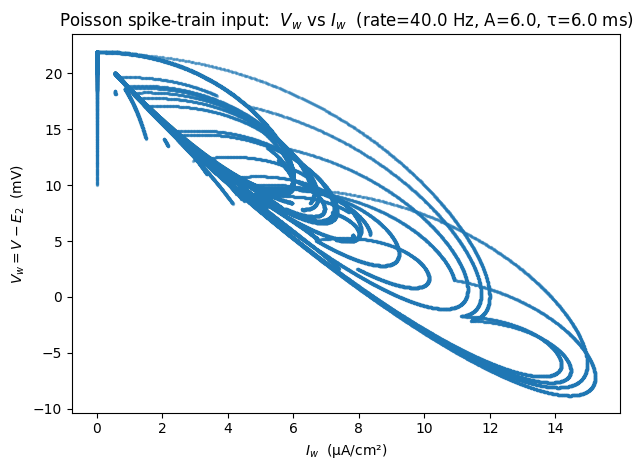

In [11]:
# Q2: Spike train current input
# TO DO: generate spike train with Poisson process and plot Vw vs Iw

# If t isn't in scope, (re)define it:
try:
    t
except NameError:
    dt = 0.01
    t = np.arange(dt, 800+dt, dt)

def poisson_spike_train_Iw(t, rate_hz=50.0, A=5.0, tau_ms=5.0): #50 spikes on avg and A is a scaling factor for strength of pulse // deafult rate
    #build a current trace by summing up all of the pulses. arrival times then follow a memerlyess poisson process.
    dt = t[1] - t[0]
    # each timsestep has a prob. of containing a spike (implemented Bernoulli thinning)
    p = rate_hz * (dt / 1000.0)
    spikes = (np.random.rand(len(t)) < p).astype(float)

    # this is the kernal for alpha with (u/tau)*exp(1 - u/tau) for u>=0 that shouldw peak at u=tau wth a height of 1)
    kernel_dur = int(np.ceil(5 * tau_ms / dt))  # 5 tau is enough
    u = np.arange(kernel_dur) * dt # shaped current puleses like alpha function.
    alpha = (u / tau_ms) * np.exp(1.0 - (u / tau_ms))
    alpha[u < 0] = 0.0
    Iw_t = A * np.convolve(spikes, alpha, mode='full')[:len(t)]
    return Iw_t, spikes

#our spike train parameters.
rate_hz = 40.0   #on average we are 40aps/s
A       = 6.0    # current scale per spike (uA/cm^2)
tau_ms  = 6.0    # pulse time constant (ms)

Iw_spike, spike_bool = poisson_spike_train_Iw(t, rate_hz, A, tau_ms)

#simulate ML with I_w as our branch input
V, w, E2 = morris_lecar_with_Iw(t, Iw_spike)
Vw = V - E2

# Plot Vw vs Iw  with the scattering helping to show the cloud like features we have going on
plt.scatter(Iw_spike, Vw, s=2, alpha=0.4)
plt.xlabel(r"$I_w$  (μA/cm²)")
plt.ylabel(r"$V_w = V - E_2$  (mV)")
plt.title(f"Poisson spike-train input:  $V_w$ vs $I_w$  (rate={rate_hz} Hz, A={A}, τ={tau_ms} ms)")
plt.tight_layout()
plt.show()


### Q2. Observation on \(V_w\) and \(I_w\)

When the input current \(I_w\) is going to ramp, we can see that the plot of \(V_w = V - E_2\) versus \(I_w\) does not form a simple one to one function. Instead, we can see that the function rises briefly and then bends downward, which would likely reflect the delayed activation of the potassium conductance. As the ramp increases, we then see that the voltage initially climbs because the potassium gate is not open. Then, once the gate responds, the potassium current will increase and pull the voltage back down, producing a non-monotonic curve rather than a simple one-to-one relationship. Additionally, for the Poisson spike-train input, the plot becomes a rather noisy cloud of points rather than a single line. Each of our incoming current pulses pushes the voltage up transiently, while the leak and gating variable dynamics are pullling it back down in between the spikes. In both cases, I would say that the key observation is that \(V_w\) is not uniquely determined by the instantaneous value of \(I_w\), and that it actually depends on the system’s internal state and the history of the input.


### Q3. Flux \(\phi_w\) versus charge \(q_w\)

The flux would be defined as \(\phi_w(t) = \int_0^t V_w(s)\,ds\), and the charge would be defined defined as \(q_w(t) = \int_0^t I_w(s)\,ds\). If we set the system up so that it behaves like a simple resistor, I believe we would find that \(\phi_w\) would be a unique function of \(q_w\). In the Morris–Lecar model, however, this should not be the case. Since the conductance now is dependent on the gating variable \(w(t)\), which evolves rather slowly and actually adds memory to the system, the same total charge can now correspond to different values of flux depending on when and how the current was delivered. This sort of path dependence means that \(\phi_w\) is not a single-valued function of \(q_w\), which would be consistent with the behavior of a memconductance element we learned about in class.
